<div style="background: linear-gradient(to bottom, #461EBE, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Pilot Training Results
Learning curve from the Mac pilot run · generation examples from the latest saved adapter.

</div>

In [189]:
import re, json, textwrap, random, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from PIL import Image, ImageDraw
import cairosvg

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, white, black, dark_bg

BG = dark_bg

## 1 · Learning Curve

In [190]:
LOG_DIR  = Path("../logs")
log_file = sorted(LOG_DIR.glob("train_mac_*.log"))[-1]   # latest run
print(f"Log: {log_file.name}  ({log_file.stat().st_size / 1024:.0f} KB)")

train_iters, train_losses = [], []
train_tok_sec, train_tokens, train_peak_mem = [], [], []
val_iters, val_losses = [], []

TRAIN_RE = re.compile(
    r"Iter (\d+): Train loss ([\d.]+), Learning Rate [\d.e+-]+, "
    r"It/sec [\d.]+, Tokens/sec ([\d.]+), Trained Tokens (\d+), Peak mem ([\d.]+) GB"
)
VAL_RE = re.compile(r"Iter (\d+): Val loss ([\d.]+)")

for line in log_file.read_text().splitlines():
    m = TRAIN_RE.match(line)
    if m:
        train_iters.append(int(m.group(1)))
        train_losses.append(float(m.group(2)))
        train_tok_sec.append(float(m.group(3)))
        train_tokens.append(int(m.group(4)))
        train_peak_mem.append(float(m.group(5)))
    m = VAL_RE.match(line)
    if m:
        val_iters.append(int(m.group(1)))
        val_losses.append(float(m.group(2)))

best_i = int(np.argmin(val_losses))
print(f"Train steps : {len(train_iters)}")
print(f"Val   steps : {len(val_iters)}")
print(f"Train loss  : {min(train_losses):.3f} \u2013 {max(train_losses):.3f}")
print(f"Val   loss  : {min(val_losses):.3f} \u2013 {max(val_losses):.3f}")
print(f"Best val    : {val_losses[best_i]:.4f} @ iter {val_iters[best_i]}")
print(f"Throughput  : {np.mean(train_tok_sec):.0f} tok/s avg  |  peak mem {max(train_peak_mem):.2f} GB")
print(f"Trained tok : {train_tokens[-1]:,} total")

Log: train_mac_20260422_111454.log  (2020 KB)
Train steps : 3750
Val   steps : 189
Train loss  : 0.397 – 1.051
Val   loss  : 0.673 – 1.118
Best val    : 0.6730 @ iter 20200
Throughput  : 814 tok/s avg  |  peak mem 14.93 GB
Trained tok : 16,815,886 total


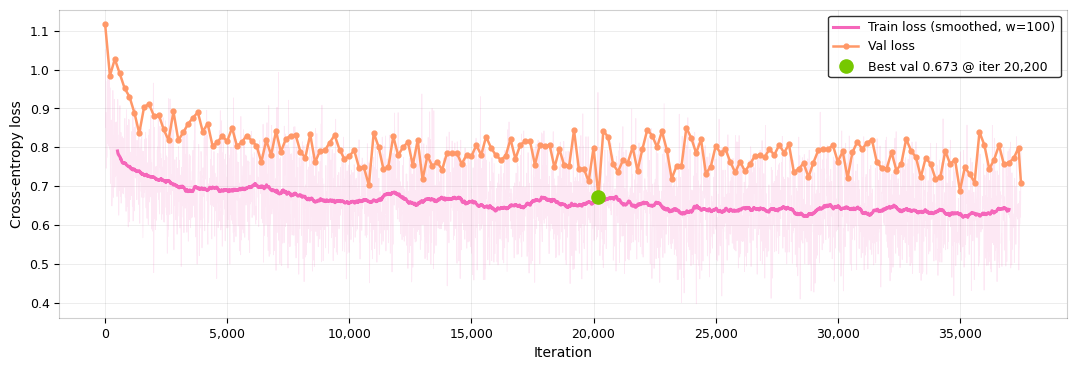

Saved → output/learning_curve.png


In [191]:
from matplotlib.ticker import FuncFormatter

W = 100   # smoothing window (train loss is very noisy per-batch)

fig, ax = plt.subplots(figsize=(13, 4), facecolor="white")
ax.set_facecolor("white")

# Raw train loss (very faint)
ax.plot(train_iters, train_losses, color=pink, alpha=0.15, linewidth=0.6)

# Smoothed train loss
if len(train_losses) >= W:
    s = np.convolve(train_losses, np.ones(W) / W, mode="valid")
    x = train_iters[W // 2 : W // 2 + len(s)]
    ax.plot(x, s, color=pink, linewidth=2.2, label=f"Train loss (smoothed, w={W})")

# Val loss
ax.plot(val_iters, val_losses, color=orange, linewidth=1.8,
        marker="o", markersize=3.5, label="Val loss")

# Best val marker
ax.scatter([val_iters[best_i]], [val_losses[best_i]], color=green, s=90, zorder=5,
           label=f"Best val {val_losses[best_i]:.3f} @ iter {val_iters[best_i]:,}")

for sp in ax.spines.values():
    sp.set_edgecolor("#00000030")
ax.tick_params(colors=black, labelsize=9)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Iteration", color=black, fontsize=10)
ax.set_ylabel("Cross-entropy loss", color=black, fontsize=10)
#ax.set_title("Pilot — Learning Curve  (Qwen2.5-Coder-1.5B + LoRA, 100k icons, 3 epochs)", color=black, fontsize=12)
ax.legend(facecolor="white", edgecolor="#00000030", labelcolor=black, fontsize=9)
ax.grid(color=black, linewidth=0.5, alpha=0.1)

Path("output").mkdir(exist_ok=True)
plt.savefig("output/learning_curve.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/learning_curve.png")

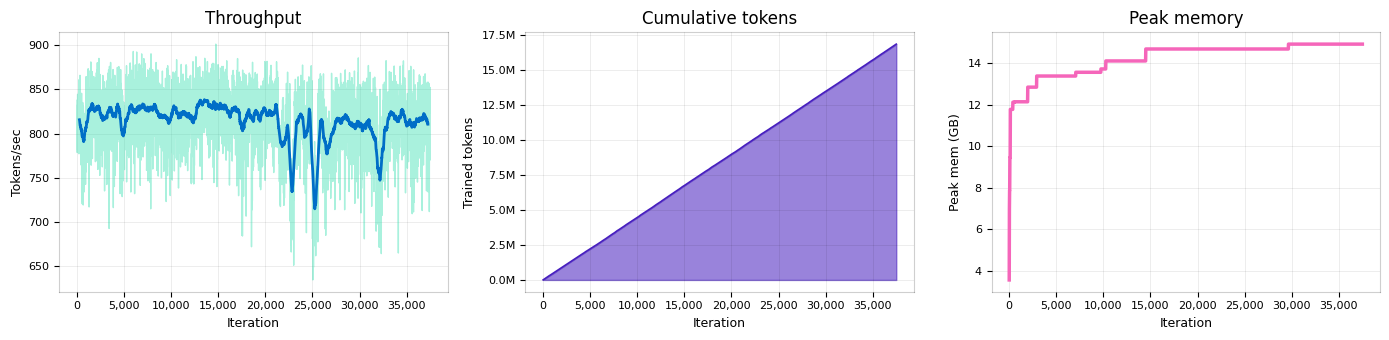

Saved → output/training_diagnostics.png


In [192]:
from matplotlib.ticker import FuncFormatter

smooth_w = 50

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), facecolor="white")

panels = [
    (train_tok_sec, "Tokens/sec",      teal,   "Throughput"),
    (train_tokens,  "Trained tokens",  purple, "Cumulative tokens"),
    (train_peak_mem,"Peak mem (GB)",   pink,   "Peak memory"),
]
for ax, (vals, ylabel, color, title) in zip(axes, panels):
    ax.set_facecolor("white")

    if title == "Throughput":
        ax.plot(train_iters, vals, color=color, linewidth=1.0, alpha=0.4)
        if len(vals) >= smooth_w:
            s = np.convolve(vals, np.ones(smooth_w) / smooth_w, mode="valid")
            xs = train_iters[smooth_w // 2 : smooth_w // 2 + len(s)]
            ax.plot(xs, s, color=blue, linewidth=2.0, zorder=5)
    elif title == "Cumulative tokens":
        vals_m = [v / 1e6 for v in vals]
        ax.fill_between(train_iters, vals_m, alpha=0.55, color=color)
        ax.plot(train_iters, vals_m, color=color, linewidth=1.2)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}M"))
    else:
        ax.plot(train_iters, vals, color=color, linewidth=2.5, alpha=1)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    for sp in ax.spines.values():
        sp.set_edgecolor("#00000030")
    ax.tick_params(colors=black, labelsize=8)
    ax.set_xlabel("Iteration", color=black, fontsize=9)
    ax.set_ylabel(ylabel, color=black, fontsize=9)
    ax.set_title(title, color=black, fontsize=12)
    ax.grid(color=black, linewidth=0.5, alpha=0.1)

#plt.suptitle("Training diagnostics", color=black, fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("output/training_diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/training_diagnostics.png")

## 2 · Sample Test Icons

In [195]:
# Render helpers — defined here so the reference preview below can use them
CARD_SZ  = 160
ICON_PAD = 16
CORNER   = 12

def _rgba(h, a=255):
    h = h.lstrip("#")
    return (int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16), a)

def make_card(svg_text, color):
    m = re.search(r"(<svg[\s\S]*?</svg>)", svg_text, re.IGNORECASE)
    svg = m.group(1) if m else svg_text
    svg = svg.replace("currentColor", color)
    svg = re.sub(r'(fill|stroke)="(black|#000|#000000)"', rf'\1="{color}"', svg)

    icon_sz = CARD_SZ - ICON_PAD * 2
    card = Image.new("RGBA", (CARD_SZ, CARD_SZ), (0, 0, 0, 0))
    mask = Image.new("L",    (CARD_SZ, CARD_SZ), 0)
    ImageDraw.Draw(mask).rounded_rectangle(
        [0, 0, CARD_SZ - 1, CARD_SZ - 1], radius=CORNER, fill=255
    )
    card.paste(Image.new("RGBA", (CARD_SZ, CARD_SZ), (255, 255, 255, 255)), mask=mask)

    try:
        png  = cairosvg.svg2png(bytestring=svg.encode(), output_width=icon_sz, output_height=icon_sz)
        icon = Image.open(BytesIO(png)).convert("RGBA")
        card.paste(icon, (ICON_PAD, ICON_PAD), icon)
    except Exception:
        ImageDraw.Draw(card).text(
            (CARD_SZ // 2, CARD_SZ // 2), "not rendered", fill=(0, 0, 0, 255), anchor="mm"
        )

    ImageDraw.Draw(card).rounded_rectangle(
        [0, 0, CARD_SZ - 1, CARD_SZ - 1], radius=CORNER, outline=_rgba(color), width=3
    )
    return card

Sampled 7 icons (first is pinned):
  · table tennis player in action, line-style icon [pinned]
  · filled smartphone with notch, circular background
  · sort icon, bold, bottom-to-top, duotone style
  · filled cake with candle, birthday icon
  · Euro symbol in a two-tone circle, simple design
  · leaf inside square, minimalist icon
  · no credit card symbol in circle


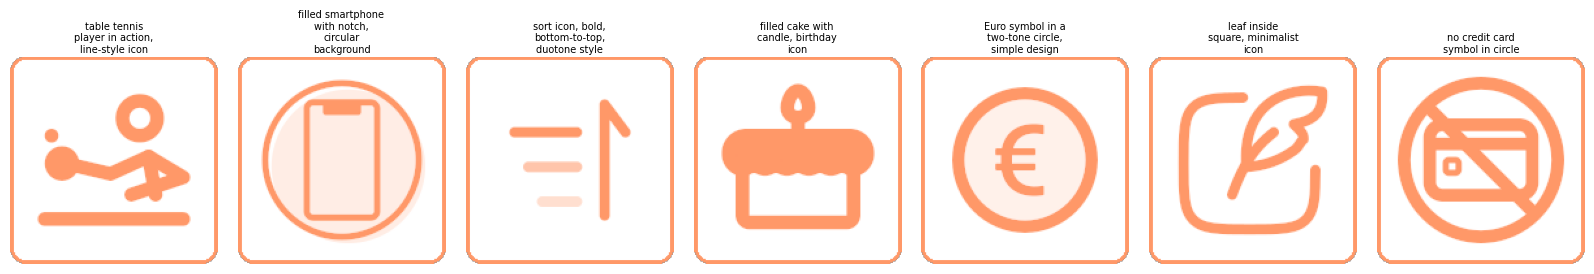

In [196]:
TIMINGS_FILE  = Path("../results/pilot/notebook_timings.json")
TEST_PATH     = Path("../data/pilot/test.jsonl")
N_SHOW        = 7
PINNED_PROMPT = "table tennis player in action, line-style icon"

def extract(record):
    msgs = {m["role"]: m["content"] for m in record["messages"]}
    return {
        "prompt":               msgs["user"].replace("Generate an SVG icon: ", ""),
        "reference":            msgs["assistant"],
        "system":               msgs["system"],
        "zeroshot":             None,
        "generated":            None,
        "generated_fused":      None,
        "generated_fused_fp16": None,
    }

all_records = [json.loads(l) for l in TEST_PATH.read_text().splitlines() if l.strip()]

# Pin first icon
pinned = next(
    r for r in all_records
    if PINNED_PROMPT in {m["content"] for m in r["messages"]}
    or any(PINNED_PROMPT in m["content"] for m in r["messages"])
)
pool   = [r for r in all_records if r is not pinned]
sample = [pinned] + random.sample(pool, N_SHOW - 1)
records = [extract(r) for r in sample]

print(f"Sampled {len(records)} icons (first is pinned):")
for i, r in enumerate(records):
    tag = " [pinned]" if i == 0 else ""
    print(f"  · {r['prompt'][:70]}{tag}")


# Reference icons preview — re-run sampling cell above for a different set
fig, axes = plt.subplots(1, len(records), figsize=(len(records) * 2.3, 2.6), facecolor="white")
fig.patch.set_facecolor("white")
for ax, rec in zip(axes, records):
    ax.imshow(make_card(rec["reference"], orange))
    ax.axis("off")
    wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=18))
    ax.set_title(wrapped, fontsize=7, color="black", pad=4, wrap=True)
plt.tight_layout()
plt.show()


## 3 · Generate
Zero-shot first (base model, no adapter), then fine-tuned. Generated sequentially to avoid holding two model instances in memory.

In [197]:
from mlx_lm import load, generate as mlx_generate

MODEL = "mlx-community/Qwen2.5-Coder-1.5B-Instruct-4bit"

def run_generation(mdl, tok, records, key):
    for i, rec in enumerate(records):
        messages = [
            {"role": "system", "content": rec["system"]},
            {"role": "user",   "content": f"Generate an SVG icon: {rec['prompt']}"},
        ]
        prompt_text = tok.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        rec[key] = mlx_generate(mdl, tok, prompt=prompt_text, max_tokens=1024, verbose=False)
        print(f"  [{i+1}/{len(records)}] {rec['prompt'][:60]}")

In [198]:
import time

print("Loading base model (zero-shot, no adapter)…")
model_base, tokenizer = load(MODEL)
print("Generating…")
t0 = time.perf_counter()
run_generation(model_base, tokenizer, records, key="zeroshot")
elapsed_zs = time.perf_counter() - t0
del model_base
print(f"Zero-shot done.  Total: {elapsed_zs:.1f}s  |  avg {elapsed_zs/len(records):.1f}s/icon")

TIMINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
_t = json.load(open(TIMINGS_FILE)) if TIMINGS_FILE.exists() else {}
_t["elapsed_zs"] = elapsed_zs
json.dump(_t, open(TIMINGS_FILE, "w"), indent=2)


Loading base model (zero-shot, no adapter)…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 155344.59it/s]


Generating…
  [1/7] table tennis player in action, line-style icon
  [2/7] filled smartphone with notch, circular background
  [3/7] sort icon, bold, bottom-to-top, duotone style
  [4/7] filled cake with candle, birthday icon
  [5/7] Euro symbol in a two-tone circle, simple design
  [6/7] leaf inside square, minimalist icon
  [7/7] no credit card symbol in circle
Zero-shot done.  Total: 30.9s  |  avg 4.4s/icon


In [199]:
ADAPTER = "../models/pilot-lora"

print("Loading fine-tuned model (with adapter)…")
model_ft, tokenizer = load(MODEL, adapter_path=ADAPTER)
print("Generating…")
t0 = time.perf_counter()
run_generation(model_ft, tokenizer, records, key="generated")
elapsed_ft = time.perf_counter() - t0
del model_ft
print(f"Fine-tuned done.  Total: {elapsed_ft:.1f}s  |  avg {elapsed_ft/len(records):.1f}s/icon")
print(f"Overhead vs zero-shot: {elapsed_ft/elapsed_zs:.2f}×")

_t = json.load(open(TIMINGS_FILE)) if TIMINGS_FILE.exists() else {}
_t["elapsed_ft"] = elapsed_ft
json.dump(_t, open(TIMINGS_FILE, "w"), indent=2)


Loading fine-tuned model (with adapter)…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 48897.33it/s]


Generating…
  [1/7] table tennis player in action, line-style icon
  [2/7] filled smartphone with notch, circular background
  [3/7] sort icon, bold, bottom-to-top, duotone style
  [4/7] filled cake with candle, birthday icon
  [5/7] Euro symbol in a two-tone circle, simple design
  [6/7] leaf inside square, minimalist icon
  [7/7] no credit card symbol in circle
Fine-tuned done.  Total: 60.7s  |  avg 8.7s/icon
Overhead vs zero-shot: 1.96×


In [200]:
import mlx.core as mx
import mlx.nn as nn
from mlx_lm.tuner.lora import LoRALinear

print("Loading fine-tuned model for 4-bit fusion…")
model_ft_fuse, tokenizer_fuse = load(MODEL, adapter_path=ADAPTER)
count = 0
for layer in model_ft_fuse.model.layers:
    attn = layer.self_attn
    for proj_name in ("q_proj", "k_proj", "v_proj", "o_proj"):
        proj = getattr(attn, proj_name, None)
        if isinstance(proj, LoRALinear):
            setattr(attn, proj_name, proj.fuse())
            count += 1
    mlp = getattr(layer, "mlp", None)
    if mlp is not None:
        for proj_name in ("gate_proj", "up_proj", "down_proj"):
            proj = getattr(mlp, proj_name, None)
            if isinstance(proj, LoRALinear):
                setattr(mlp, proj_name, proj.fuse())
                count += 1
mx.eval(model_ft_fuse.parameters())
print(f"Replaced {count} LoRALinear layers with fused nn.QuantizedLinear.")
t0 = time.perf_counter()
run_generation(model_ft_fuse, tokenizer_fuse, records, key="generated_fused")
elapsed_fused = time.perf_counter() - t0
del model_ft_fuse
print(f"Fused (4-bit) done.  Total: {elapsed_fused:.1f}s  |  avg {elapsed_fused/len(records):.1f}s/icon")

_t = json.load(open(TIMINGS_FILE)) if TIMINGS_FILE.exists() else {}
_t["elapsed_fused"] = elapsed_fused
json.dump(_t, open(TIMINGS_FILE, "w"), indent=2)


Loading fine-tuned model for 4-bit fusion…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 112682.79it/s]


Replaced 112 LoRALinear layers with fused nn.QuantizedLinear.
  [1/7] table tennis player in action, line-style icon
  [2/7] filled smartphone with notch, circular background
  [3/7] sort icon, bold, bottom-to-top, duotone style
  [4/7] filled cake with candle, birthday icon
  [5/7] Euro symbol in a two-tone circle, simple design
  [6/7] leaf inside square, minimalist icon
  [7/7] no credit card symbol in circle
Fused (4-bit) done.  Total: 35.5s  |  avg 5.1s/icon


In [201]:
def fuse_lora_fp16(lora_layer):
    """Merge LoRA adapter into base weights in float16 — exact, no re-quantisation.

    MLX-LM LoRA forward: z = scale * x @ lora_a @ lora_b
    Weight-space delta:   ΔW = scale * (lora_a @ lora_b).T
                             = scale * lora_b.T @ lora_a.T
    """
    base  = lora_layer.linear  # nn.QuantizedLinear
    W     = mx.dequantize(
        base.weight, base.scales, base.biases,
        base.group_size, base.bits,
    ).astype(mx.float16)
    delta    = (lora_layer.scale * lora_layer.lora_b.T @ lora_layer.lora_a.T).astype(mx.float16)
    W_merged = W + delta
    out_dims, in_dims = W_merged.shape
    lin_bias = getattr(base, "bias", None)
    fused = nn.Linear(input_dims=in_dims, output_dims=out_dims, bias=lin_bias is not None)
    fused.weight = W_merged
    if lin_bias is not None:
        fused.bias = lin_bias
    return fused

print("Loading fine-tuned model for float16 fusion…")
model_ft_fp16, tokenizer_fp16 = load(MODEL, adapter_path=ADAPTER)
count = 0
for layer in model_ft_fp16.model.layers:
    attn = layer.self_attn
    for proj_name in ("q_proj", "k_proj", "v_proj", "o_proj"):
        proj = getattr(attn, proj_name, None)
        if isinstance(proj, LoRALinear):
            setattr(attn, proj_name, fuse_lora_fp16(proj))
            count += 1
    mlp = getattr(layer, "mlp", None)
    if mlp is not None:
        for proj_name in ("gate_proj", "up_proj", "down_proj"):
            proj = getattr(mlp, proj_name, None)
            if isinstance(proj, LoRALinear):
                setattr(mlp, proj_name, fuse_lora_fp16(proj))
                count += 1
mx.eval(model_ft_fp16.parameters())
print(f"Replaced {count} LoRALinear layers with fused float16 nn.Linear.")
t0 = time.perf_counter()
run_generation(model_ft_fp16, tokenizer_fp16, records, key="generated_fused_fp16")
elapsed_fused_fp16 = time.perf_counter() - t0
del model_ft_fp16
print(f"Fused (fp16) done.  Total: {elapsed_fused_fp16:.1f}s  |  avg {elapsed_fused_fp16/len(records):.1f}s/icon")

_t = json.load(open(TIMINGS_FILE)) if TIMINGS_FILE.exists() else {}
_t["elapsed_fused_fp16"] = elapsed_fused_fp16
json.dump(_t, open(TIMINGS_FILE, "w"), indent=2)


Loading fine-tuned model for float16 fusion…


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 84072.91it/s]


Replaced 112 LoRALinear layers with fused float16 nn.Linear.
  [1/7] table tennis player in action, line-style icon
  [2/7] filled smartphone with notch, circular background
  [3/7] sort icon, bold, bottom-to-top, duotone style
  [4/7] filled cake with candle, birthday icon
  [5/7] Euro symbol in a two-tone circle, simple design
  [6/7] leaf inside square, minimalist icon
  [7/7] no credit card symbol in circle
Fused (fp16) done.  Total: 66.6s  |  avg 9.5s/icon


## 4 · Comparison Grid

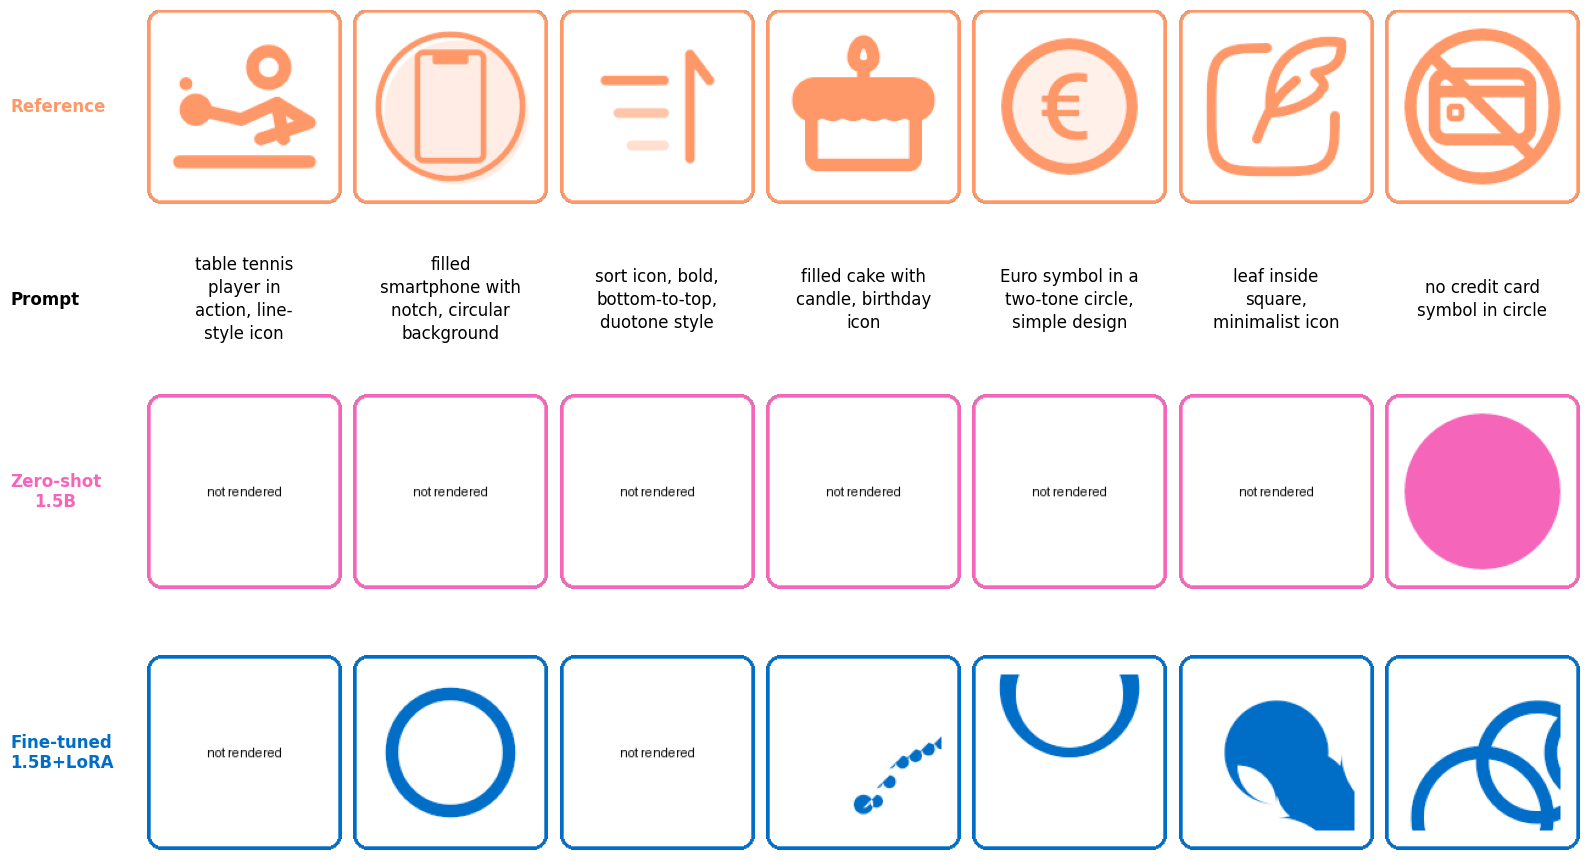

Saved → output/pilot_comparison_grid.png


In [205]:
ROW_META = [
    ("Reference",             orange, "reference"),
    ("Prompt",                black,  "prompt"),
    ("Zero-shot\n1.5B",       pink,   "zeroshot"),
    ("Fine-tuned\n1.5B+LoRA", blue,   "generated"),
]
N_ROWS = len(ROW_META)
N_COLS = len(records)

fig = plt.figure(figsize=(N_COLS * 2.3, N_ROWS * 2.4), facecolor="white")
gs  = gridspec.GridSpec(
    N_ROWS, N_COLS, figure=fig,
    height_ratios=[2.2, 0.75, 2.2, 2.2],
    hspace=0.30, wspace=0.06,
    left=0.09, right=0.98, top=0.91, bottom=0.02,
)

col0_axes = {}
for col_i, rec in enumerate(records):
    for row_i, (label, color, key) in enumerate(ROW_META):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.set_facecolor("white")
        ax.axis("off")
        if col_i == 0:
            col0_axes[row_i] = ax

        if key == "prompt":
            wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=16))
            ax.text(0.5, 0.5, wrapped, ha="center", va="center", fontsize=12,
                    color=color, transform=ax.transAxes,
                    multialignment="center", linespacing=1.35)
        else:
            ax.imshow(make_card(rec[key], color))

for row_i, (label, color, _) in enumerate(ROW_META):
    pos = col0_axes[row_i].get_position()
    fig.text(
        0.005, pos.y0 + pos.height / 2, label,
        ha="left", va="center", fontsize=12, color=color,
        fontweight="bold", multialignment="center",
    )

#fig.suptitle("Pilot — Reference  ·  Zero-shot (1.5B)  ·  Fine-tuned (1.5B + LoRA, latest adapter)", color=black, fontsize=10.5, y=0.97,)

Path("output").mkdir(exist_ok=True)
plt.savefig("output/pilot_comparison_grid.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/pilot_comparison_grid.png")

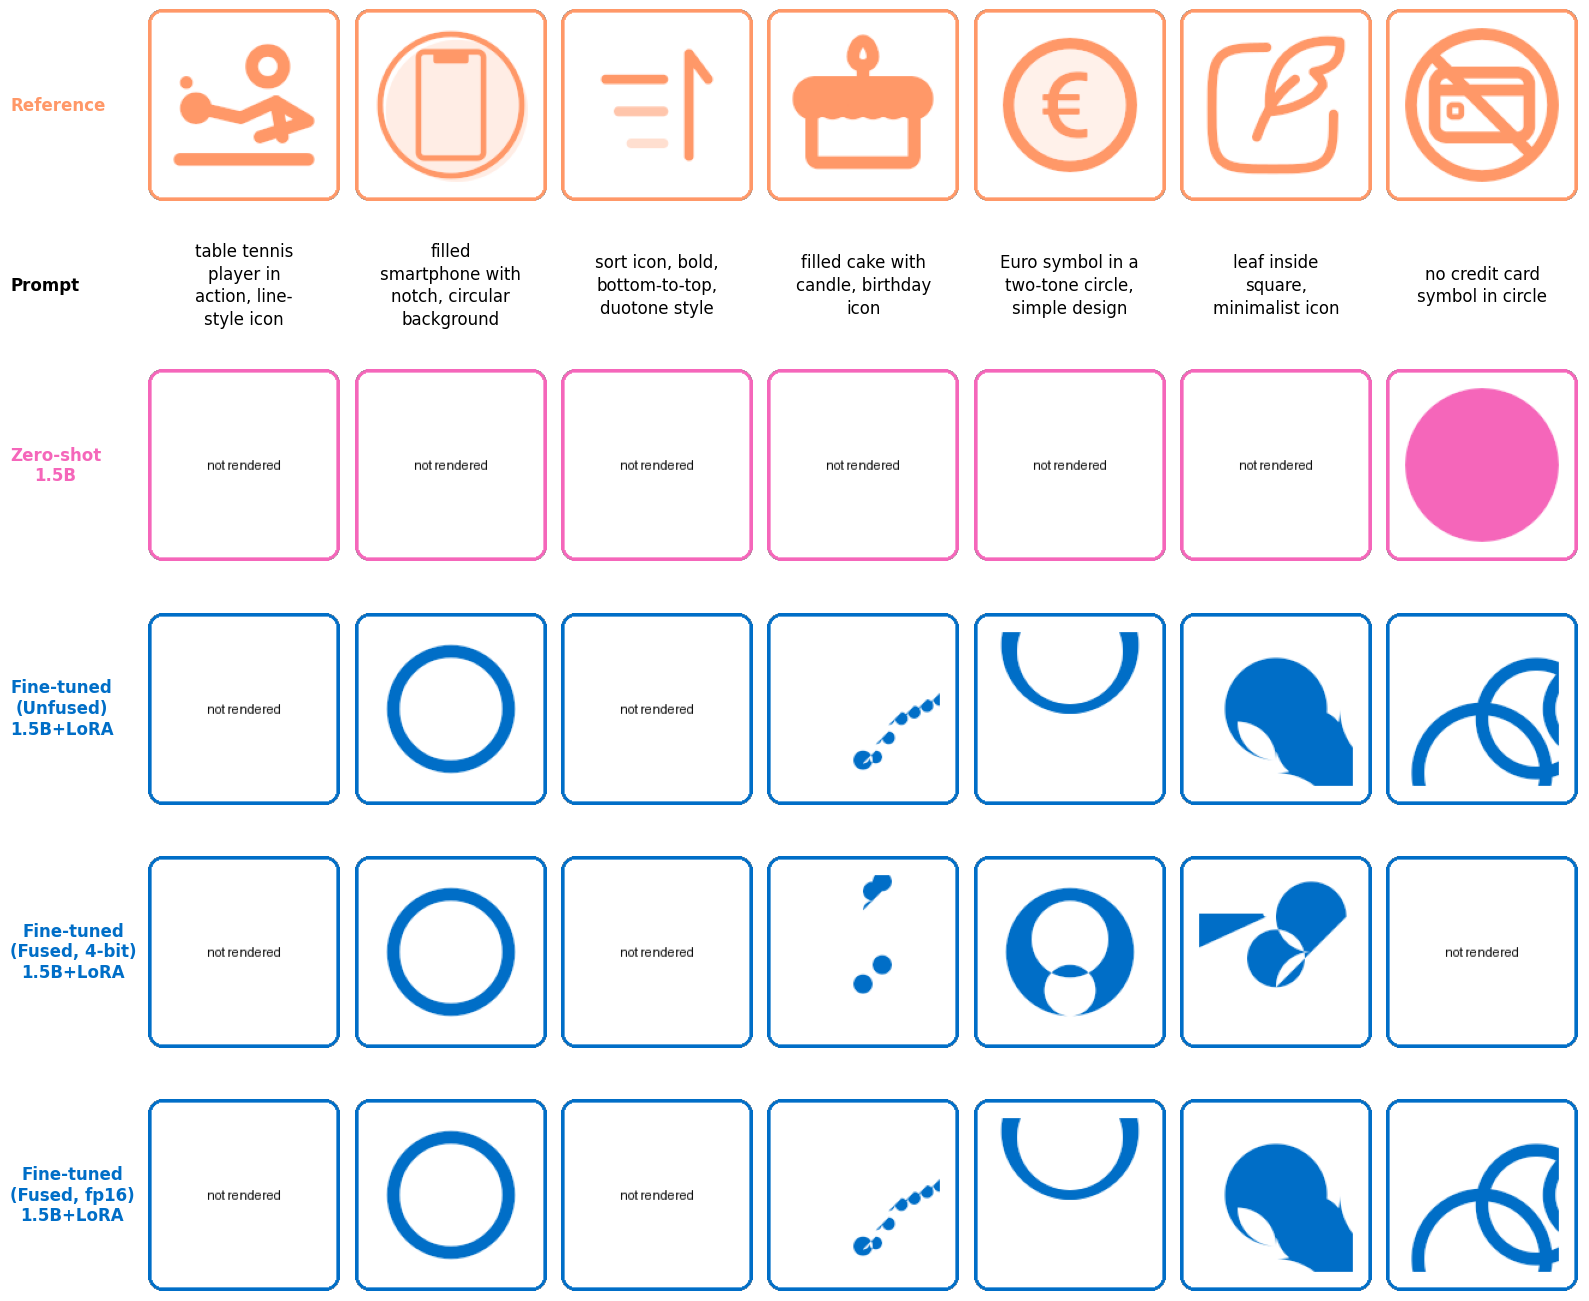

Saved → output/pilot_comparison_grid_fused.png


In [206]:
ROW_META_BOTH = [
    ("Reference",                        orange, "reference"),
    ("Prompt",                           black,  "prompt"),
    ("Zero-shot\n1.5B",                  pink,   "zeroshot"),
    ("Fine-tuned\n(Unfused)\n1.5B+LoRA", blue,   "generated"),
    ("Fine-tuned\n(Fused, 4-bit)\n1.5B+LoRA", blue, "generated_fused"),
    ("Fine-tuned\n(Fused, fp16)\n1.5B+LoRA", blue, "generated_fused_fp16"),
]
N_ROWS = len(ROW_META_BOTH)
N_COLS = len(records)

fig = plt.figure(figsize=(N_COLS * 2.3, N_ROWS * 2.4), facecolor="white")
gs  = gridspec.GridSpec(
    N_ROWS, N_COLS, figure=fig,
    height_ratios=[2.2, 0.75, 2.2, 2.2, 2.2, 2.2],
    hspace=0.30, wspace=0.06,
    left=0.09, right=0.98, top=0.91, bottom=0.02,
)

col0_axes = {}
for col_i, rec in enumerate(records):
    for row_i, (label, color, key) in enumerate(ROW_META_BOTH):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.set_facecolor("white")
        ax.axis("off")
        if col_i == 0:
            col0_axes[row_i] = ax

        if key == "prompt":
            wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=16))
            ax.text(0.5, 0.5, wrapped, ha="center", va="center", fontsize=12,
                    color=color, transform=ax.transAxes,
                    multialignment="center", linespacing=1.35)
        else:
            ax.imshow(make_card(rec[key], color))

for row_i, (label, color, _) in enumerate(ROW_META_BOTH):
    pos = col0_axes[row_i].get_position()
    fig.text(
        0.005, pos.y0 + pos.height / 2, label,
        ha="left", va="center", fontsize=12, color=color,
        fontweight="bold", multialignment="center",
    )

Path("output").mkdir(exist_ok=True)
plt.savefig("output/pilot_comparison_grid_fused.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/pilot_comparison_grid_fused.png")


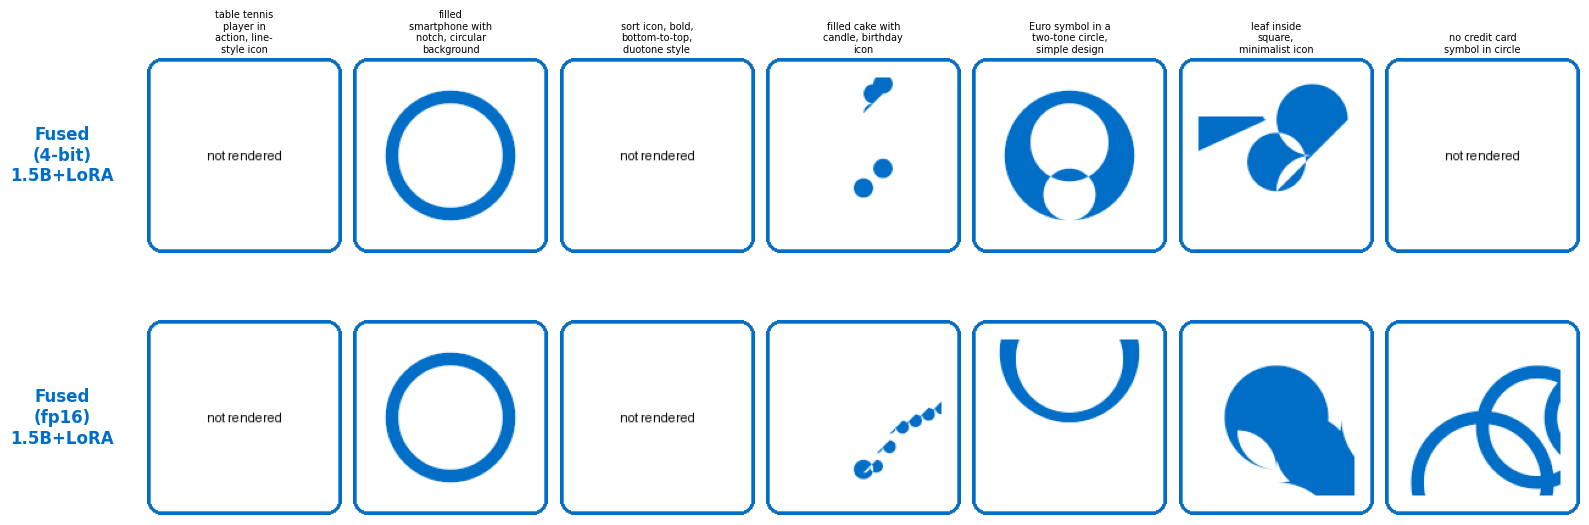

Saved → output/pilot_fusion_comparison.png


In [207]:
# Fusion comparison — 4-bit vs fp16, for Adapter Fusion section
ROW_META_FUSION = [
    ("Fused\n(4-bit)\n1.5B+LoRA",  blue, "generated_fused"),
    ("Fused\n(fp16)\n1.5B+LoRA",    blue, "generated_fused_fp16"),
]
N_ROWS = len(ROW_META_FUSION)
N_COLS = len(records)

fig = plt.figure(figsize=(N_COLS * 2.3, N_ROWS * 2.4 + 0.6), facecolor="white")
gs  = gridspec.GridSpec(
    N_ROWS, N_COLS, figure=fig,
    height_ratios=[2.2, 2.2],
    hspace=0.30, wspace=0.06,
    left=0.09, right=0.98, top=0.88, bottom=0.02,
)

col0_axes = {}
for col_i, rec in enumerate(records):
    for row_i, (label, color, key) in enumerate(ROW_META_FUSION):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.set_facecolor("white")
        ax.axis("off")
        if col_i == 0:
            col0_axes[row_i] = ax
        if row_i == 0:
            wrapped = "\n".join(textwrap.wrap(rec["prompt"], width=16))
            ax.set_title(wrapped, fontsize=7, color="black", pad=4)
        ax.imshow(make_card(rec[key], color))

for row_i, (label, color, _) in enumerate(ROW_META_FUSION):
    pos = col0_axes[row_i].get_position()
    fig.text(
        0.005, pos.y0 + pos.height / 2, label,
        ha="left", va="center", fontsize=12, color=color,
        fontweight="bold", multialignment="center",
    )

Path("output").mkdir(exist_ok=True)
plt.savefig("output/pilot_fusion_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → output/pilot_fusion_comparison.png")


In [208]:
_t = json.load(open(TIMINGS_FILE))
elapsed_zs         = _t["elapsed_zs"]
elapsed_ft         = _t["elapsed_ft"]
elapsed_fused      = _t["elapsed_fused"]
elapsed_fused_fp16 = _t["elapsed_fused_fp16"]

n = len(records)
rows = [
    ("Zero-shot (no adapter)",      elapsed_zs,         1.0),
    ("Fine-tuned — unfused",        elapsed_ft,         elapsed_ft         / elapsed_zs),
    ("Fine-tuned — fused (4-bit)",  elapsed_fused,      elapsed_fused      / elapsed_zs),
    ("Fine-tuned — fused (fp16)",   elapsed_fused_fp16, elapsed_fused_fp16 / elapsed_zs),
]

col_w = [28, 10, 12, 10]
sep   = "─" * (sum(col_w) + len(col_w) * 3 + 1)
hdr   = f"{'Model':<{col_w[0]}} │ {'Total':>{col_w[1]}} │ {'s / icon':>{col_w[2]}} │ {'vs zeroshot':>{col_w[3]}}"

print(sep)
print(f"{'Generation time summary':^{len(sep)}}")
print(f"{'(7 icons, same prompts)':^{len(sep)}}")
print(sep)
print(hdr)
print(sep)
for label, t, ratio in rows:
    marker = "  ← fastest" if ratio == min(r for _, _, r in rows) else ""
    print(f"{label:<{col_w[0]}} │ {t:>{col_w[1]-1}.1f}s │ {t/n:>{col_w[2]-1}.1f}s │ {ratio:>{col_w[3]-1}.2f}×{marker}")
print(sep)

# ── Update timing table in appendix.tex ─────────────────────────────────
TEX = Path("../study/sections/appendix.tex")
tex_rows = [
    ("Zero-shot (no adapter)",        elapsed_zs,         1.0),
    ("Fine-tuned --- unfused",         elapsed_ft,         elapsed_ft         / elapsed_zs),
    ("Fine-tuned --- fused (4-bit)",   elapsed_fused,      elapsed_fused      / elapsed_zs),
    ("Fine-tuned --- fused (float16)", elapsed_fused_fp16, elapsed_fused_fp16 / elapsed_zs),
]
lines = TEX.read_text().split("\n")
out   = []
for line in lines:
    replaced = False
    for label, elapsed, ratio in tex_rows:
        if label in line and "&" in line:
            prefix = line[: line.index("&")]
            out.append(f"{prefix}& {elapsed:.1f}\\,s & {elapsed/n:.1f}\\,s & {ratio:.2f}$\\times$ \\\\")
            replaced = True
            break
    if not replaced:
        out.append(line)
TEX.write_text("\n".join(out))
print(f"\nAppendix timing table updated → {TEX}")


─────────────────────────────────────────────────────────────────────────
                         Generation time summary                         
                         (7 icons, same prompts)                         
─────────────────────────────────────────────────────────────────────────
Model                        │      Total │     s / icon │ vs zeroshot
─────────────────────────────────────────────────────────────────────────
Zero-shot (no adapter)       │      30.9s │         4.4s │      1.00×  ← fastest
Fine-tuned — unfused         │      60.7s │         8.7s │      1.96×
Fine-tuned — fused (4-bit)   │      35.5s │         5.1s │      1.15×
Fine-tuned — fused (fp16)    │      66.6s │         9.5s │      2.16×
─────────────────────────────────────────────────────────────────────────

Appendix timing table updated → ../study/sections/appendix.tex
